In [83]:
from tme3 import *
from tme2 import *
import matplotlib.pyplot as plt
from mltools import plot_data, plot_frontiere, make_grid, gen_arti
from functools import partial
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Perceptron and `Linear` Class

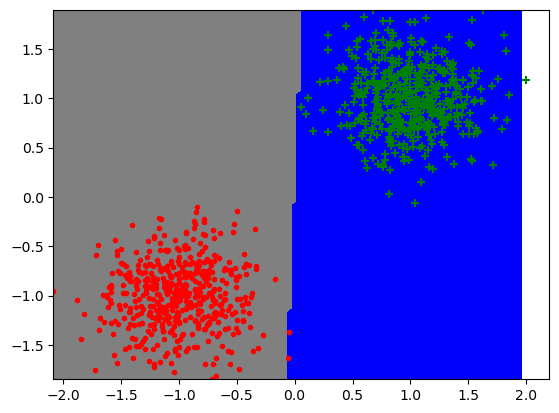

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/ML/tme/tme03/src/tme3.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


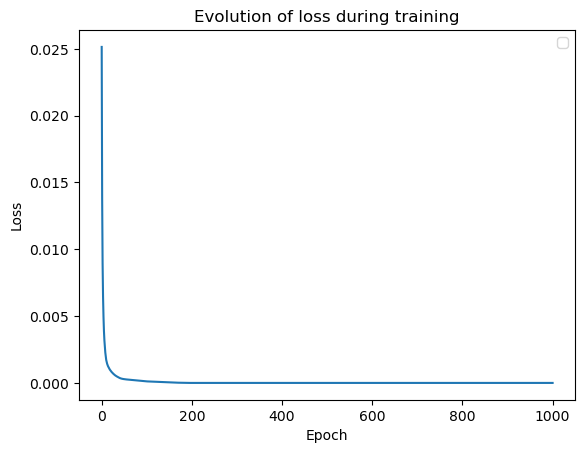

In [84]:
X_train, y_train = gen_arti(nbex=1000, data_type=0, epsilon=0.1)
lm = Linear(loss=perceptron_loss, loss_g=perceptron_grad, max_iter=1000, eps=0.1)
lm.fit(X_train, y_train)
plot_frontiere(X_train, lambda x: lm.predict(x), step=100)
plot_data(X_train, y_train)
plt.show()
lm.plot_losses()

# USPS Data, Mini-batch, SGD

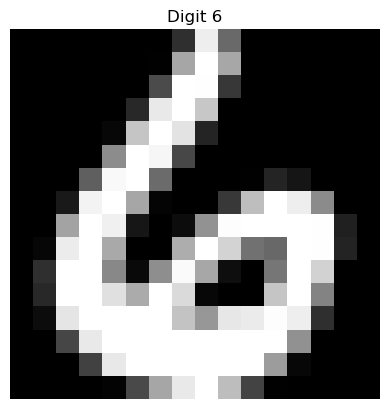

In [85]:
X_train_all, y_train_all = load_usps("../data/USPS_train.txt")
X_test_all, y_test_all = load_usps("../data/USPS_test.txt")
pos, neg = 5, 6
if neg == -1:
    y_train_all  = np.where(y_train_all == pos, pos, -1)
    y_test_all  = np.where(y_test_all == pos, pos, -1)
X_train, y_train = get_usps([neg,pos],X_train_all,y_train_all)
X_test, y_test = get_usps([neg,pos],X_test_all,y_test_all)

y_train = np.where(y_train == pos,1,-1 )
y_test = np.where(y_test == pos,1,-1 )

i = 0
show_usps(X_train[i], pos if y_train[i] == 1 else neg)


Train perceptron: 

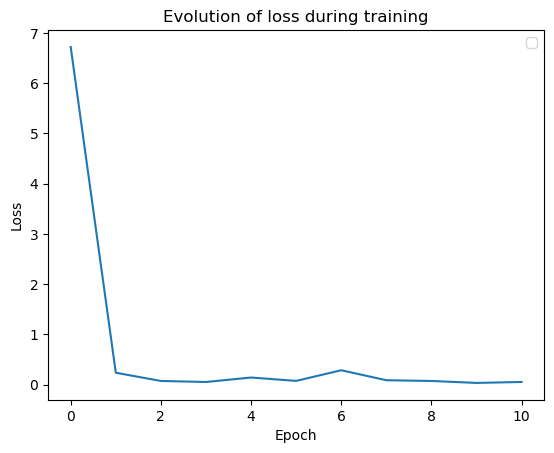

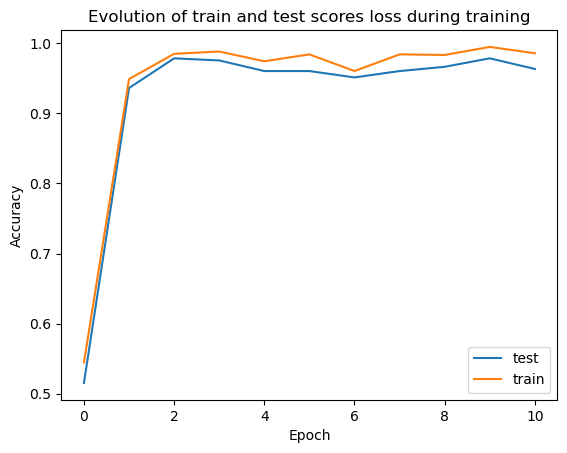

Accuracy: 0.9636363636363636


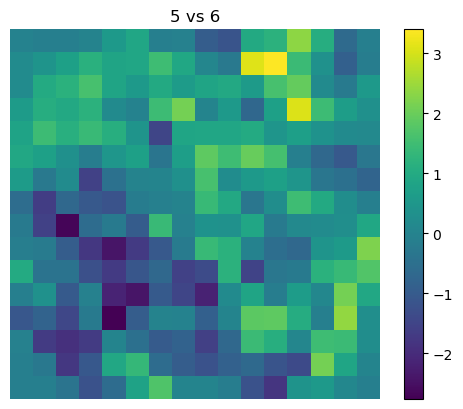

In [86]:
lm = Linear(loss=perceptron_loss, loss_g=perceptron_grad,max_iter=10, eps=0.1)
lm.fit(X_train, y_train, X_test, y_test, w_init=-0.1, m=1)
lm.plot_losses()
lm.plot_scores()
print(f"Accuracy: {lm.score(X_test, y_test)}")
lm.show_w(f"{pos} vs {neg if neg != -1 else "rest"}")

Weights resemble learned digits!

SGD converges much faster, even for noisy data:

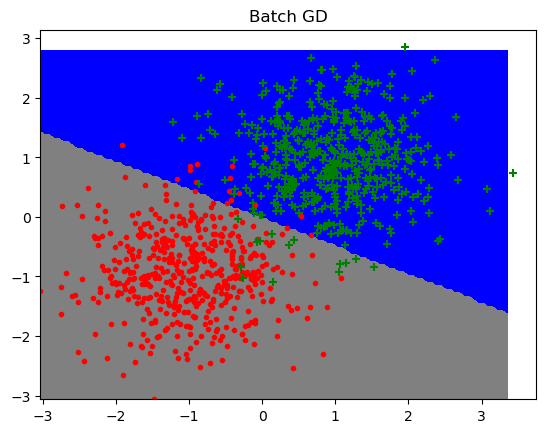

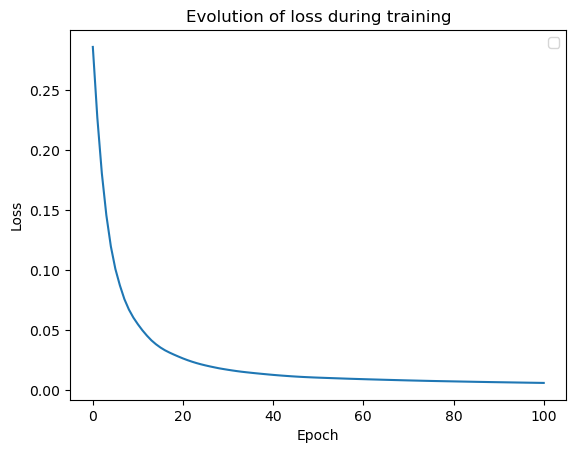

In [87]:
X_train, y_train = gen_arti(nbex=1000, data_type=0, sigma=0.5)
lm = Linear(loss=perceptron_loss, loss_g=perceptron_grad, max_iter=100, eps=0.1)
lm.fit(X_train, y_train, m=None)
plot_frontiere(X_train, lambda x: lm.predict(x), step=100)
plot_data(X_train, y_train)
plt.title("Batch GD")
plt.show()
lm.plot_losses()

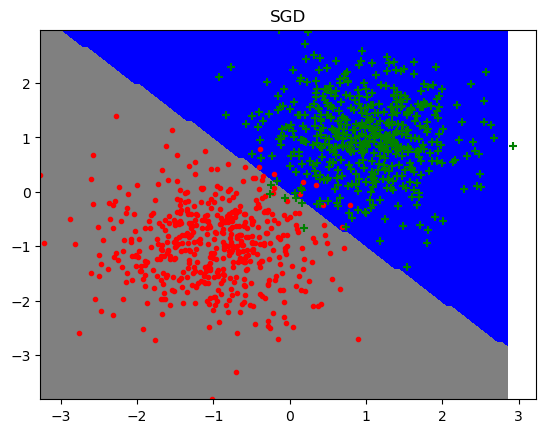

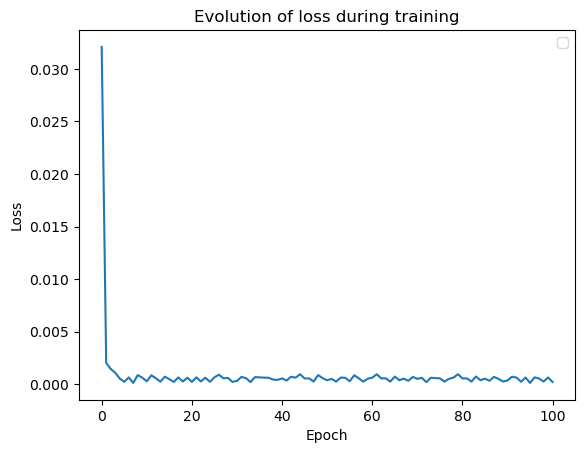

In [88]:
X_train, y_train = gen_arti(nbex=1000, data_type=0, sigma=0.5)
lm = Linear(loss=perceptron_loss, loss_g=perceptron_grad, max_iter=100, eps=0.1)
lm.fit(X_train, y_train, m=1)
plot_frontiere(X_train, lambda x: lm.predict(x), step=100)
plot_data(X_train, y_train)
plt.title("SGD")
plt.show()
lm.plot_losses()

# Projections and Regularization

(1000, 2)


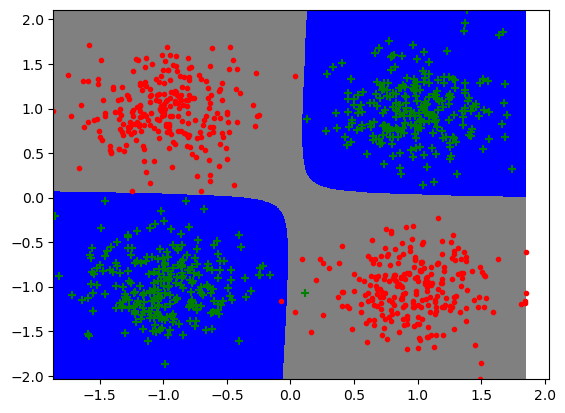

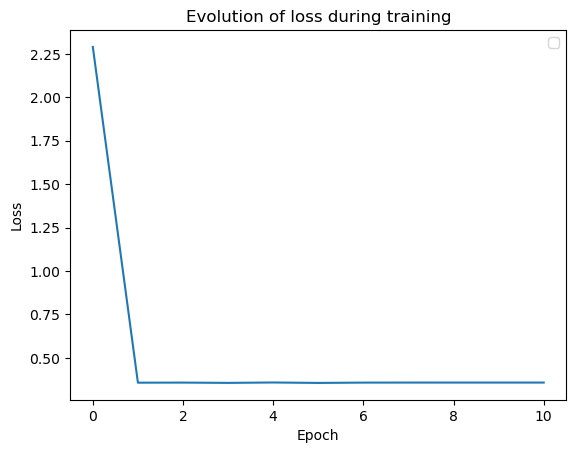

In [89]:
X_train, y_train = gen_arti(nbex=1000, data_type=1, epsilon=0.1)
alpha, lam = 1, 0.1 # TODO: play with regularization
poly = Linear(loss=partial(hinge_loss, alpha=alpha, lam=lam), 
              loss_g=partial(hinge_grad, alpha=alpha, lam=lam), 
              phi = proj_poly, max_iter=10, eps=0.01)
poly.fit(X_train, y_train, m=1)
print(X_train.shape)
plot_frontiere(X_train, lambda x: poly.predict(x), step=1000)
plot_data(X_train, y_train)
plt.show()
poly.plot_losses()

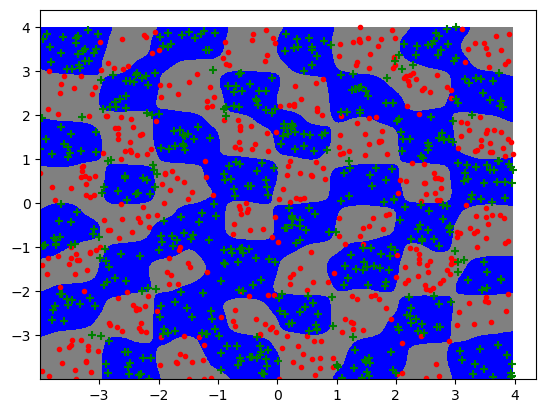

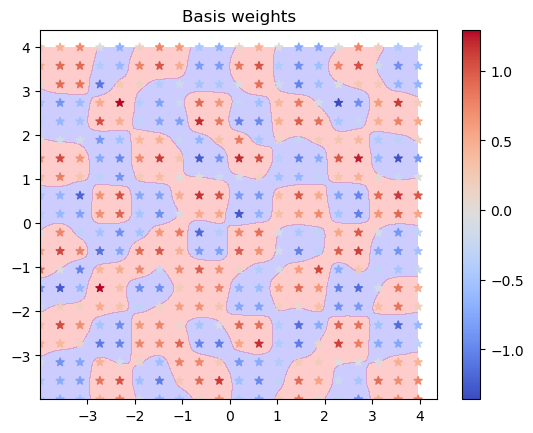

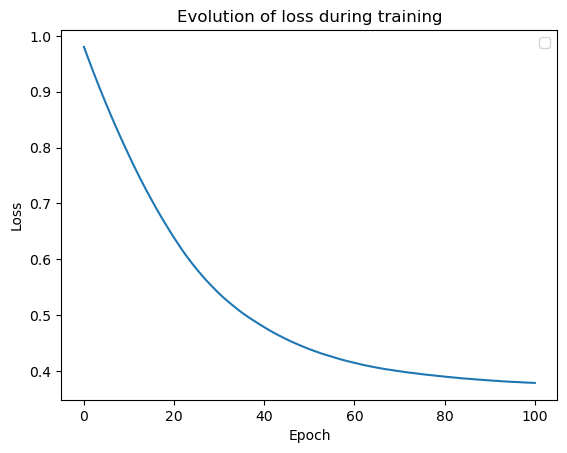

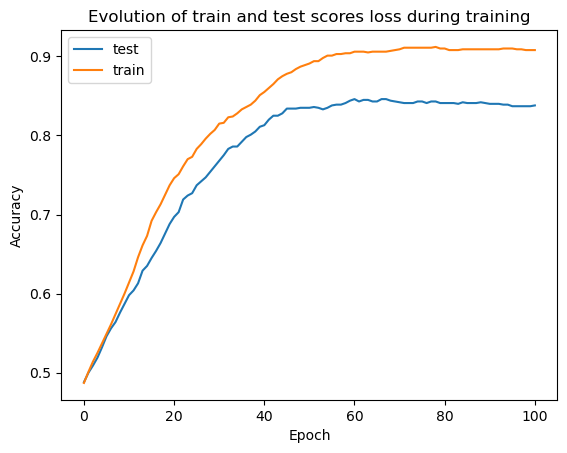

Accuracy: 0.838


In [93]:
X_train, y_train = gen_arti(nbex=1000, data_type=2, epsilon=0.01, sigma=0.01)
X_test, y_test = gen_arti(nbex=1000, data_type=2, epsilon=0.01, sigma=0.01)
basis = linspace_basis(X_train, 20)
alpha, lam = 1, 0.001 # TODO: play with regularization
rbf = Linear(loss=partial(hinge_loss, alpha=alpha, lam=lam), 
             loss_g=partial(hinge_grad, alpha=alpha, lam=lam), 
             phi = partial(proj_gaus, 
                            basis=basis, 
                            sigma=0.2), # TODO: play with sigma
            max_iter=100, eps=0.01)
rbf.fit(X_train, y_train,X_test, y_test, m=1)
plot_frontiere(X_train, lambda x: rbf.predict(x), step=1000)
plot_data(X_train, y_train)
plt.show()
plot_frontiere(X_train, lambda x: rbf.predict(x), step=1000,colors=("blue", "red"), alpha=0.2)
plt.scatter(basis[:,0],basis[:,1],marker="*", c = rbf.w, cmap="coolwarm")
plt.title("Basis weights")
plt.colorbar()
plt.show()
rbf.plot_losses()
plt.show()
rbf.plot_scores()
print(f"Accuracy: {rbf.score(X_test, y_test)}")

Higher lambda - smoother contours, only few basis points contribute to decision, which is not what we want for chessboard problem (strong regularization make model underfit). Alpha - margin threshold, can be fixed to 1 like in SVM, since w can also be scaled without effect to decision boundary.

# SVM and Grid Search

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV

In [ ]:
X_train_all, y_train_all = load_usps("../data/USPS_train.txt")
X_test_all, y_test_all = load_usps("../data/USPS_test.txt")
pos, neg = 7, 8
if neg == -1:
    y_train_all  = np.where(y_train_all == pos, pos, -1)
    y_test_all  = np.where(y_test_all == pos, pos, -1)
X_train, y_train = get_usps([neg,pos],X_train_all,y_train_all)
X_test, y_test = get_usps([neg,pos],X_test_all,y_test_all)

y_train = np.where(y_train == pos,1,-1 )
y_test = np.where(y_test == pos,1,-1 )

In [ ]:
perc = Perceptron()
knn = KNeighborsClassifier(5)
tree = DecisionTreeClassifier()

model = perc
model.fit(X_train, y_train)
print(f"Accuracy {model.score(X_test, y_test)}")

Accuracy 0.9776357827476039


For SVC implemented in `scikitlearn`:
- margin (alpha in our code) is fixed to 1
- `C` is inverse of `lam`
- RBF takes all training points as basis, but only several support vectors will have non-zero coefficients
- it uses kernel trick, so RBF is much more efficient (doesn't explicitly project points, in fact projection is infinite-dimensional)
- `gamma` is for RBF: $\gamma = \frac1{2\sigma^2}$

In [ ]:
param_grid = {
    'kernel': ["rbf"],
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [10, 1, 0.1, 0.01]
}

grid = GridSearchCV(estimator=SVC(),param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [10, 1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

/Users/vlad/miniconda3/envs/ml/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


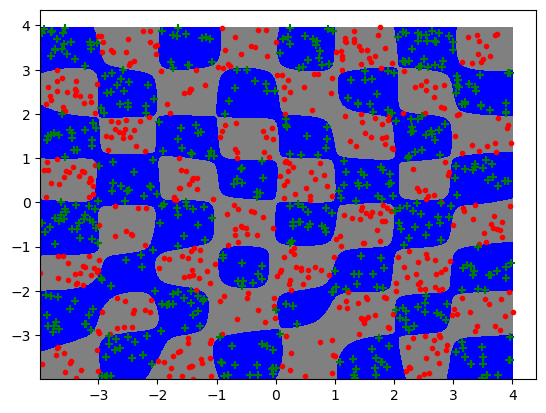

Accuracy: 0.912


In [ ]:
svm = SVC(C=1000, kernel="rbf", gamma=1, probability=True) 
X_train, y_train = gen_arti(nbex=1000, data_type=2, epsilon=0.01, sigma=0.01)
X_test, y_test = gen_arti(nbex=1000, data_type=2, epsilon=0.01, sigma=0.01)

svm.fit(X_train, y_train)
plot_frontiere(X_train, lambda x: svm.predict(x), step=1000)
plot_data(X_train, y_train)
plt.show()
print(f"Accuracy: {svm.score(X_test, y_test)}")

In [ ]:
def plot_frontiere_proba(data, f, step, alpha):
    grid, x, y = make_grid(data=data, step=step)
    plt.contour(x,y,f(grid).reshape(x.shape), 255, cmap="coolwarm", alpha=alpha)

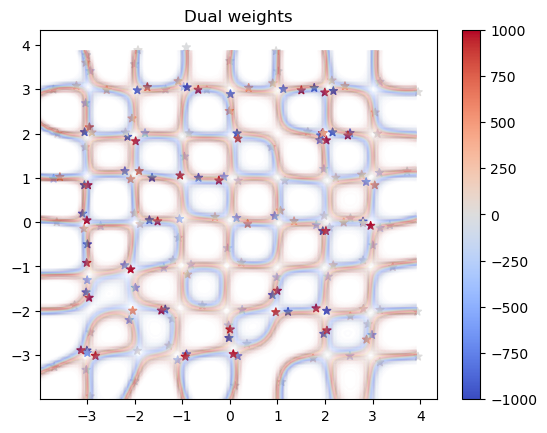

In [ ]:
SVs = svm.support_vectors_
plot_frontiere_proba(X_train, lambda x: svm.predict_proba(x)[:,0], step=100, alpha=0.01)
# TODO: why colors seem inverted?
plt.scatter(SVs[:,0],SVs[:,1],marker="*", c = svm.dual_coef_, cmap="coolwarm")
plt.title("Dual weights")
plt.colorbar()
plt.show()

### TODO: learning curve for SVM with scikitlearn?

# String Kernel

In [124]:
def string_kernel(s, t, n, lam):
    """
    String subsequence kernel (Lodhi et al.)
    
    :param s: first string
    :param t: second string
    :param n: subsequence length
    :param lam: gap penalty (lambda <= 1)
    """

    m, l = len(s), len(t)

    if n == 0:
        return 1.0
    if m == 0 or l == 0:
        return 0.0

    # K[k][i][j] :
    # common subseqs of length k ending at s[i-1], t[j-1]
    K = np.zeros((n+1, m+1, l+1))

    # E is accumulator for fast summation
    E = np.zeros((n+1, m+1, l+1))

    # base case: subsequences of length 0
    K[0,:,:] = 1.0
    E[0,:,:] = 1.0

    for k in range(1, n+1):
        for i in range(1, m+1):
            for j in range(1, l+1):

                if s[i-1] == t[j-1]:
                    K[k,i,j] = lam**2 * E[k-1,i-1,j-1]
                else:
                    K[k,i,j] = 0.0

                # update accumulator along t-axis
                E[k,i,j] = lam * E[k,i,j-1] + K[k,i,j]

    # sum over all endpoints for subsequences of length n
    return np.sum(K[n,:,:])
    

In [126]:
string_kernel("aba", "aa",2,0.5) # -> 0.03125

np.float64(0.0)

In [31]:
def get_subseqs(s, n):
    if n == 1:
        return [(ch,i,i)  for i, ch in enumerate(s)]
    subseqs = []
    for i, ch in enumerate(s):
        smaller_substrings = get_subseqs(s[i:], n-1)
        for ss, i_start, i_end  in smaller_substrings:
            i_start += 1
            i_end += 1
            subseqs.append( (ch + ss, i_start, i_end) )
    return subseqs

In [32]:
get_subseqs("aba",2)

[('aa', 1, 1),
 ('ab', 2, 2),
 ('aa', 3, 3),
 ('bb', 1, 1),
 ('ba', 2, 2),
 ('aa', 1, 1)]

In [143]:
s = "pama"
t = "mapa"
u = ""
n = 3
idx = [[], []]
for i, c1 in enumerate(s):
    for j, c2 in enumerate(t):
        if c1 == c2:
            idx[0].append(i)
            idx[1].append(j)
idx = np.array(idx).T
idx

array([[0, 2],
       [1, 1],
       [1, 3],
       [2, 0],
       [3, 1],
       [3, 3]])

In [ ]:
curr_len = 0
for id1 in idx:
    for id2 in idx:
        if np.all(id1 > id2):
            curr_len += 1

_IncompleteInputError: incomplete input (2344695519.py, line 1)

In [108]:
for start in range(idx.shape[0]-n+1):
    end = start + n-1
    l = idx[end] - idx[start]-1
    # print(l > 0)
    # if np.all(l >= 0):
    print(l)


[0 0]
[ 1 -3]
[0 0]
